In [1]:
import pandas as pd
df = pd.read_csv('student_performance.csv')

# Data wala mul row 5 balamu
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


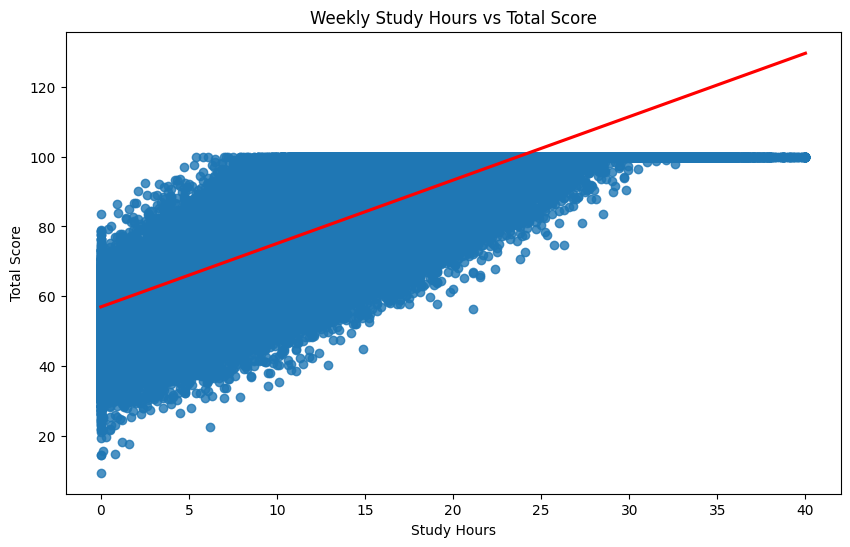

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Study hours saha Total Score athara sambandaya balamu
plt.figure(figsize=(10, 6))
sns.regplot(x='weekly_self_study_hours', y='total_score', data=df, line_kws={"color": "red"})
plt.title('Weekly Study Hours vs Total Score')
plt.xlabel('Study Hours')
plt.ylabel('Total Score')
plt.show()

In [3]:
# Wadak nathi columns ain karamu
df_cleaned = df.drop(['student_id', 'grade'], axis=1)

# Dan data thiyena hati balamu
print(df_cleaned.head())

# Check if there are any empty (null) values
print("\nMissing values check:")
print(df_cleaned.isnull().sum())

   weekly_self_study_hours  attendance_percentage  class_participation  \
0                     18.5                   95.6                  3.8   
1                     14.0                   80.0                  2.5   
2                     19.5                   86.3                  5.3   
3                     25.7                   70.2                  7.0   
4                     13.4                   81.9                  6.9   

   total_score  
0         97.9  
1         83.9  
2        100.0  
3        100.0  
4         92.0  

Missing values check:
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

# Features (Api predict karanna use karana dewal)
X = df_cleaned.drop('total_score', axis=1)

# Target (Api predict karanna ona de)
y = df_cleaned['total_score']

# Data bedamu (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (152289, 3)
Testing data size: (38073, 3)


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Model eka create karamu
model = LinearRegression()


In [6]:
# 2. Model ekata data deela train karamu
model.fit(X_train, y_train)


LinearRegression()

In [7]:
# 3. Predict karala balamu (Exam eka thiyamu)
predictions = model.predict(X_test)


In [8]:
# 4. Accuracy eka balamu
print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("R2 Score (Accuracy):", r2_score(y_test, predictions))

Mean Absolute Error: 7.116467523987491
R2 Score (Accuracy): 0.6625089353771928


In [9]:
#Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

# Model eka hadamu (N trees = 100 kiyala gannawa)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

#Accuracy
print("Random Forest Mean Absolute Error:", mean_absolute_error(y_test, rf_predictions))
print("Random Forest R2 Score:", r2_score(y_test, rf_predictions))

Random Forest Mean Absolute Error: 6.527828366992945
Random Forest R2 Score: 0.6712481516953223


In [10]:
#make  artificial neural network (deep learning)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Neural Network structure
dl_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Input Layer
    Dense(32, activation='relu'),                                 # Hidden Layer
    Dense(1)                                                      # Output Layer (Score eka nisa)
])

# Compile
dl_model.compile(optimizer='adam', loss='mean_squared_error')

# Train  (Epochs = 10 ganna)
dl_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

#  Predict
dl_predictions = dl_model.predict(X_test)

#  Accuracy
print("Neural Network R2 Score:", r2_score(y_test, dl_predictions))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3808/3808 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 293.6351 - val_loss: 106.7363
Epoch 2/10
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 97.3554 - val_loss: 79.7810
Epoch 3/10
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 78.9592 - val_loss: 69.5558
Epoch 4/10
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 72.9243 - val_loss: 74.0410
Epoch 5/10
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 72.0748 - val_loss: 68.4222
Epoch 6/10
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 71.2878 - val_loss: 68.0606
Epoch 7/10
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 70.9819 - val_loss: 73.5991
Epoch 8/10
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 70.8587 - val_loss: 70.5598
Epoch 9/10
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 70.7991 - val_loss: 68.5320
Epoch 10/10
3808/3808 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 70.0625 - val_loss: 67.4608
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 1s 988us/step
Neural Network R2 Score: 0.7165866865084656


/tmp/ipython-input-1116330523.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')


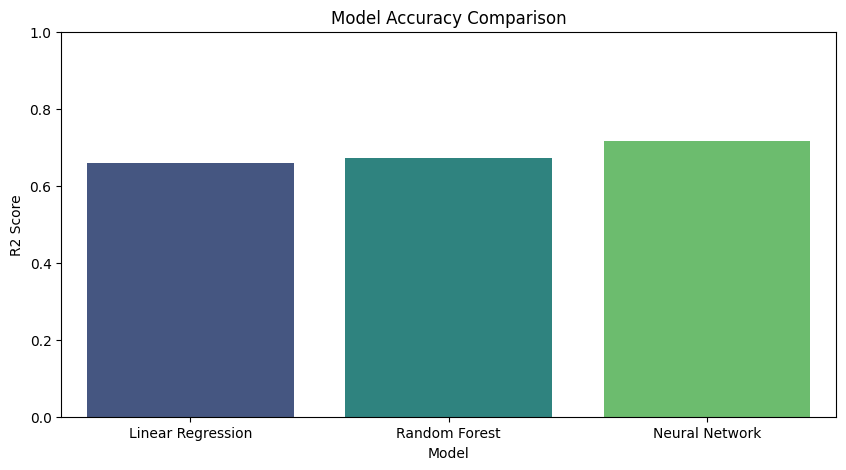

               Model  R2 Score
0  Linear Regression  0.660000
1      Random Forest  0.671248
2     Neural Network  0.716587


In [11]:
#comparison
import pandas as pd

# Results table
results = {
    'Model': ['Linear Regression', 'Random Forest', 'Neural Network'],
    'R2 Score': [0.66, r2_score(y_test, rf_predictions), r2_score(y_test, dl_predictions)]
}

results_df = pd.DataFrame(results)

# Graph
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1) # 0 to 100%
plt.show()

print(results_df)

In [12]:
import numpy as np

def predict_score(hours, attendance, participation):
    # Model ekata therenna data format karamu
    input_data = np.array([[hours, attendance, participation]])

    # Deep Learning model eka use karala predict karamu
    prediction = dl_model.predict(input_data)

    return prediction[0][0]

# Udaharanayak widiyata:
# Satiyata paya 20k paadam karana, 90% attendance thiyena, 8/10 participation thiyena student kenek
my_score = predict_score(20, 90, 8)

print(f"Predicted Total Score: {my_score:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted Total Score: 97.32


In [14]:
#save the model
import joblib

# ML models save karanna (.pkl files)
joblib.dump(model, 'linear_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')

# Deep Learning model eka aluth format ekata save karamu
dl_model.save('neural_network_model.keras')

print("Model saved in new format!")

print("All models saved successfully!")

Model saved in new format!
All models saved successfully!
